<a href="https://colab.research.google.com/github/MEH-WISH777/MEH-WISH777/blob/main/Titanic_ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Data Preprocessing for Logistic Regression

Before training a logistic regression model, it's essential to preprocess the data. This involves handling missing values and converting categorical features into a numerical format.

Now that missing values are handled, we need to convert categorical features ('Sex', 'Embarked') into numerical form using one-hot encoding.

In [ ]:
# Convert 'Sex' and 'Embarked' categorical features to numerical using one-hot encoding
train_df = pd.get_dummies(train_df, columns=['Sex', 'Embarked'], drop_first=True)
test_df = pd.get_dummies(test_df, columns=['Sex', 'Embarked'], drop_first=True)

# Display the first few rows of the processed training data
print("Train DataFrame after encoding:")
display(train_df.head())

print("\nTest DataFrame after encoding:")
display(test_df.head())

Train DataFrame after encoding:


,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,True,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,False,False,True
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,True,False,True



Test DataFrame after encoding:


,PassengerId,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_male,Embarked_Q,Embarked_S
0,892,3,"Kelly, Mr. James",34.5,0,0,330911,7.8292,True,True,False
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",47.0,1,0,363272,7.0000,False,False,True
2,894,2,"Myles, Mr. Thomas Francis",62.0,0,0,240276,9.6875,True,True,False
3,895,3,"Wirz, Mr. Albert",27.0,0,0,315154,8.6625,True,False,True
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",22.0,1,1,3101298,12.2875,False,False,True


In [ ]:
X = train_df.drop(['PassengerId', 'Name', 'Ticket', 'Survived'], axis=1)
y = train_df['Survived']

print("Shape of X (features):", X.shape)
print("Shape of y (target):", y.shape)

X.head()

Shape of X (features): (891, 8)
Shape of y (target): (891,)


,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True


**Reasoning**:
First, I will impute the missing 'Fare' values in the `test_df` using the mean 'Fare' from the `train_df`. Then, I will drop the specified columns ('PassengerId', 'Name', 'Ticket') from `test_df` and reorder the remaining columns to match the `X` (training features) DataFrame, storing the result in a new DataFrame called `test_df_processed`.



In [ ]:
test_df['Fare'] = test_df['Fare'].fillna(train_df['Fare'].mean())

# Prepare test_df to match X
test_df_processed = test_df[X.columns]

print("Missing 'Fare' values in test_df after imputation:")
print(test_df['Fare'].isnull().sum())
print("\nFirst few rows of test_df_processed:")
display(test_df_processed.head())
print("\nShape of test_df_processed:", test_df_processed.shape)
print("Columns of test_df_processed match X columns:", list(test_df_processed.columns) == list(X.columns))

Missing 'Fare' values in test_df after imputation:
0

First few rows of test_df_processed:


,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,34.5,0,0,7.8292,True,True,False
1,3,47.0,1,0,7.0000,False,False,True
2,2,62.0,0,0,9.6875,True,True,False
3,3,27.0,0,0,8.6625,True,False,True
4,3,22.0,1,1,12.2875,False,False,True



Shape of test_df_processed: (418, 8)
Columns of test_df_processed match X columns: True


**Reasoning**:
The next step in the preprocessing is to convert all boolean columns in both the training features (`X`) and the preprocessed test features (`test_df_processed`) to integer type, which is necessary for many machine learning models.



In [ ]:
X = X.astype({'Sex_male': int, 'Embarked_Q': int, 'Embarked_S': int})
test_df_processed = test_df_processed.astype({'Sex_male': int, 'Embarked_Q': int, 'Embarked_S': int})

print("X DataFrame after boolean to integer conversion:")
display(X.head())

print("\nTest DataFrame after boolean to integer conversion:")
display(test_df_processed.head())

X DataFrame after boolean to integer conversion:


,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,1,0,1
1,1,38.0,1,0,71.2833,0,0,0
2,3,26.0,0,0,7.9250,0,0,1
3,1,35.0,1,0,53.1000,0,0,1
4,3,35.0,0,0,8.0500,1,0,1



Test DataFrame after boolean to integer conversion:


,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,34.5,0,0,7.8292,1,1,0
1,3,47.0,1,0,7.0000,0,0,1
2,2,62.0,0,0,9.6875,1,1,0
3,3,27.0,0,0,8.6625,1,0,1
4,3,22.0,1,1,12.2875,0,0,1


**Reasoning**:
The next step is to apply `StandardScaler` to the numerical features of both the training and test datasets. It's crucial to fit the scaler only on the training data to prevent data leakage and then transform both datasets.



In [ ]:
from sklearn.preprocessing import StandardScaler

# Identify numerical features to scale (excluding one-hot encoded and Pclass which might be treated as categorical by some models)
numerical_features = ['Age', 'SibSp', 'Parch', 'Fare']

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training data and transform both training and test data
X[numerical_features] = scaler.fit_transform(X[numerical_features])
test_df_processed[numerical_features] = scaler.transform(test_df_processed[numerical_features])

print("X DataFrame after numerical feature scaling:")
display(X.head())

print("\nTest DataFrame after numerical feature scaling:")
display(test_df_processed.head())

X DataFrame after numerical feature scaling:


,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,-0.592481,0.432793,-0.473674,-0.502445,1,0,1
1,1,0.638789,0.432793,-0.473674,0.786845,0,0,0
2,3,-0.284663,-0.474545,-0.473674,-0.488854,0,0,1
3,1,0.407926,0.432793,-0.473674,0.420730,0,0,1
4,3,0.407926,-0.474545,-0.473674,-0.486337,1,0,1



Test DataFrame after numerical feature scaling:


,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,0.369449,-0.474545,-0.473674,-0.490783,1,1,0
1,3,1.331378,0.432793,-0.473674,-0.507479,0,0,1
2,2,2.485693,-0.474545,-0.473674,-0.453367,1,1,0
3,3,-0.207709,-0.474545,-0.473674,-0.474005,1,0,1
4,3,-0.592481,0.432793,0.767630,-0.401017,0,0,1


# Task
Continue with data preprocessing by imputing the missing 'Fare' value in the test data with the training data's mean 'Fare', then align the test data's columns with the training features by dropping 'PassengerId', 'Name', and 'Ticket', and ensuring column order. Convert all boolean columns in both training features and preprocessed test features to integer type. Afterward, apply `StandardScaler` to the numerical features, fitting only on the training data and transforming both datasets. Perform Exploratory Data Analysis (EDA) including generating histograms for numerical features, creating a correlation heatmap, and comparing feature distributions between 'Survived' and 'Not Survived' groups. Subsequently, train a Logistic Regression model on the scaled training data and evaluate its performance using a Confusion Matrix, Accuracy, Precision, Recall, and F1-Score. Finally, generate 'Survived' predictions on the scaled test data and create a 'submission.csv' file with 'PassengerId' and the predictions, then summarize the entire process.

## Complete Test Data Preprocessing

### Subtask:
Handle the missing 'Fare' value in `test_df` by imputing it with the mean of 'Fare' from the training data. Then, prepare `test_df` by dropping 'PassengerId', 'Name', and 'Ticket' and ensuring its columns and their order match the training features `X`.


## Exploratory Data Analysis (EDA)

### Subtask:
Generate histograms for numerical features to visualize their distributions, create a correlation heatmap of all features in the training data to understand relationships, and compare key feature distributions (e.g., 'Age', 'Fare') between 'Survived' and 'Not Survived' groups.


**Reasoning**:
The first step in performing EDA is to import the necessary libraries for plotting, `matplotlib.pyplot` and `seaborn`.



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries 'matplotlib.pyplot' and 'seaborn' imported successfully.")

Libraries 'matplotlib.pyplot' and 'seaborn' imported successfully.


**Reasoning**:
The next step is to generate histograms for each numerical feature in the `X` DataFrame to visualize their distributions, as outlined in the subtask instructions.



Generating histograms for numerical features...


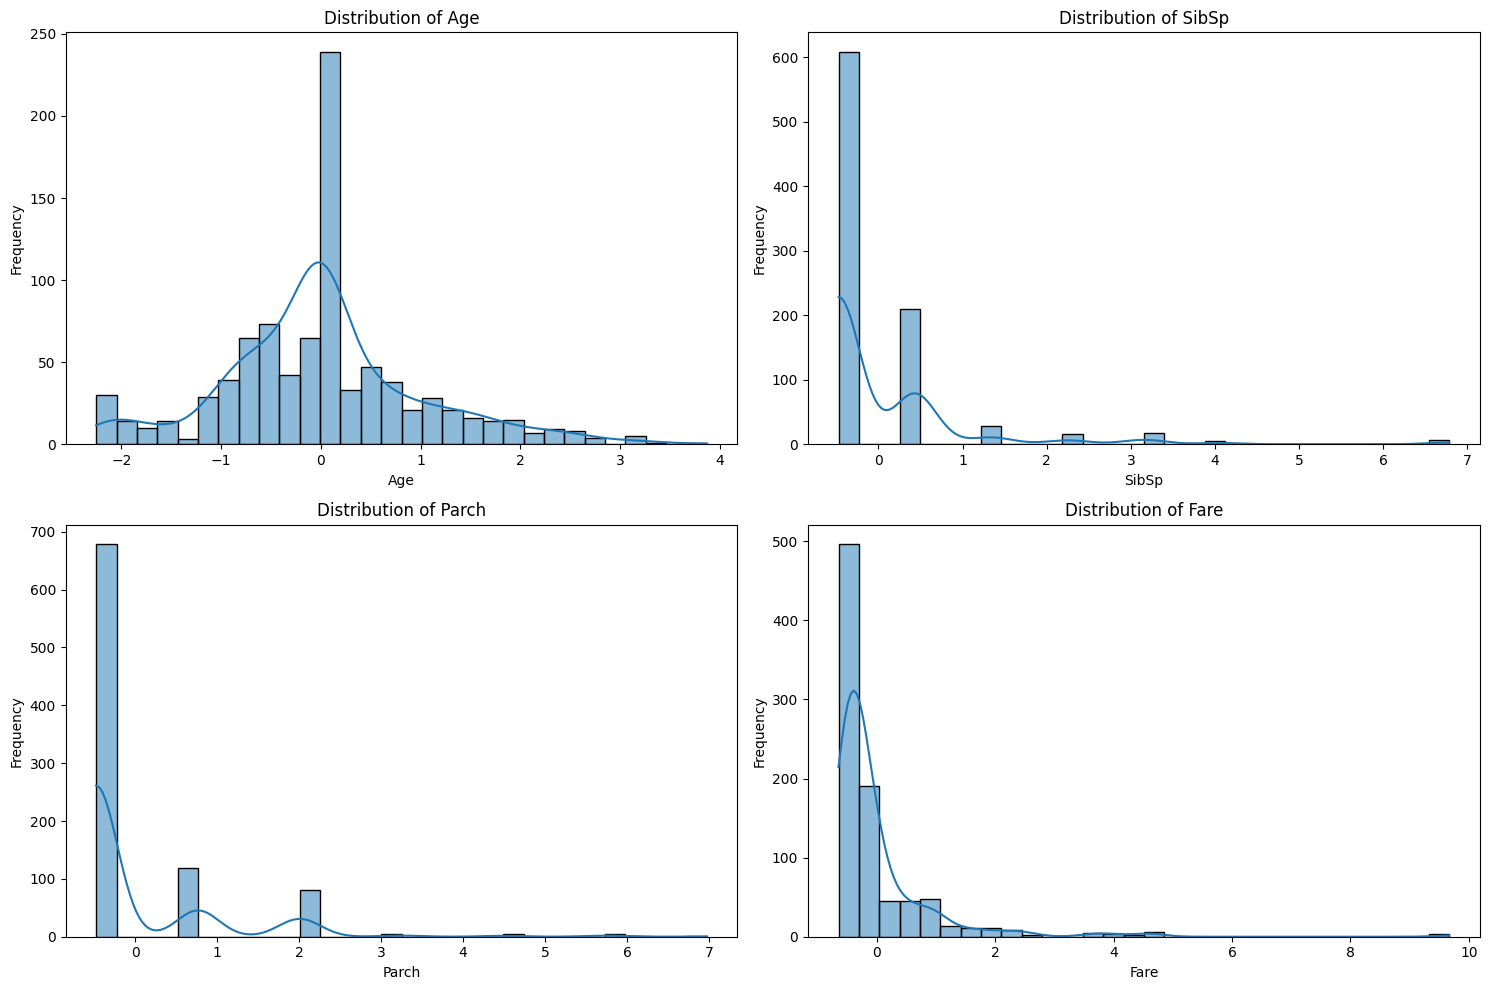

Histograms generated successfully.


In [ ]:
print("Generating histograms for numerical features...")

# Create histograms for each numerical feature in X
plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(2, 2, i + 1) # Arrange plots in a 2x2 grid
    sns.histplot(X[feature], kde=True, bins=30) # Using sns.histplot for better aesthetics
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print("Histograms generated successfully.")

**Reasoning**:
The next step is to combine the features DataFrame `X` and the target Series `y` into a single DataFrame. This is necessary to calculate the correlation matrix, which should include the 'Survived' target variable, as per the subtask instructions.



In [ ]:
print("Concatenating X and y for correlation analysis...")

train_df_eda = pd.concat([X, y], axis=1)

print("First few rows of combined DataFrame (train_df_eda):")
display(train_df_eda.head())
print("Shape of combined DataFrame (train_df_eda):", train_df_eda.shape)

Concatenating X and y for correlation analysis...
First few rows of combined DataFrame (train_df_eda):


,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,Survived
0,3,-0.592481,0.432793,-0.473674,-0.502445,1,0,1,0
1,1,0.638789,0.432793,-0.473674,0.786845,0,0,0,1
2,3,-0.284663,-0.474545,-0.473674,-0.488854,0,0,1,1
3,1,0.407926,0.432793,-0.473674,0.420730,0,0,1,1
4,3,0.407926,-0.474545,-0.473674,-0.486337,1,0,1,0


Shape of combined DataFrame (train_df_eda): (891, 9)


**Reasoning**:
The next step is to calculate the correlation matrix for the combined DataFrame `train_df_eda` and visualize it using a seaborn heatmap, as specified in the subtask instructions, to understand the relationships between all features, including the target variable 'Survived'.



Generating correlation heatmap...


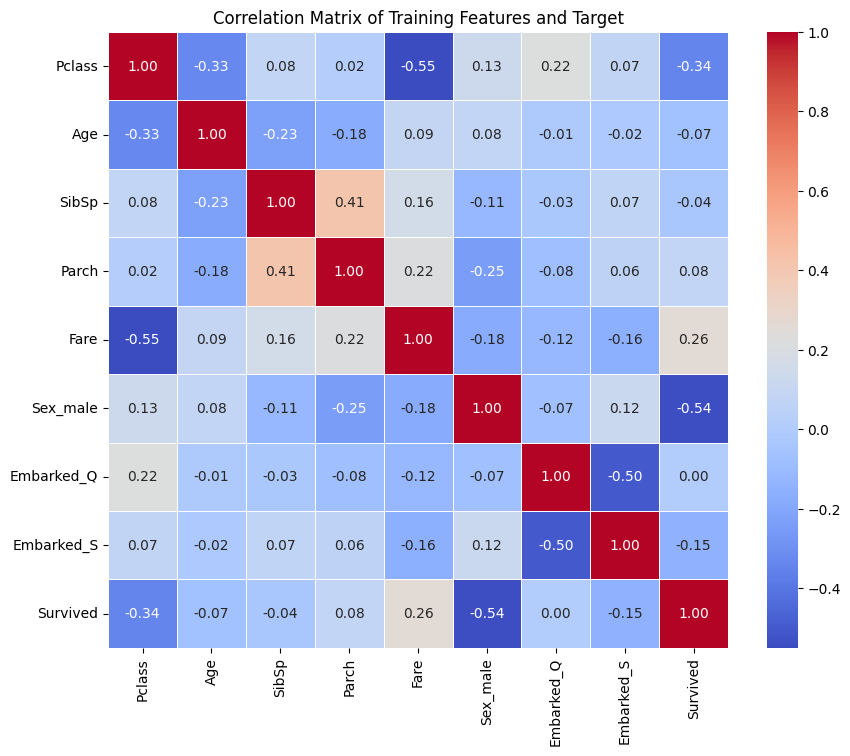

Correlation heatmap generated successfully.


In [ ]:
print("Generating correlation heatmap...")

# Calculate the correlation matrix
correlation_matrix = train_df_eda.corr()

# Create a heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Training Features and Target')
plt.show()

print("Correlation heatmap generated successfully.")

**Reasoning**:
The final step for the EDA subtask is to compare the distributions of key numerical features ('Age' and 'Fare') between the 'Survived' and 'Not Survived' groups using distribution plots with the 'Survived' column as the hue, as per the instructions.



Comparing 'Age' and 'Fare' distributions between Survived and Not Survived groups...


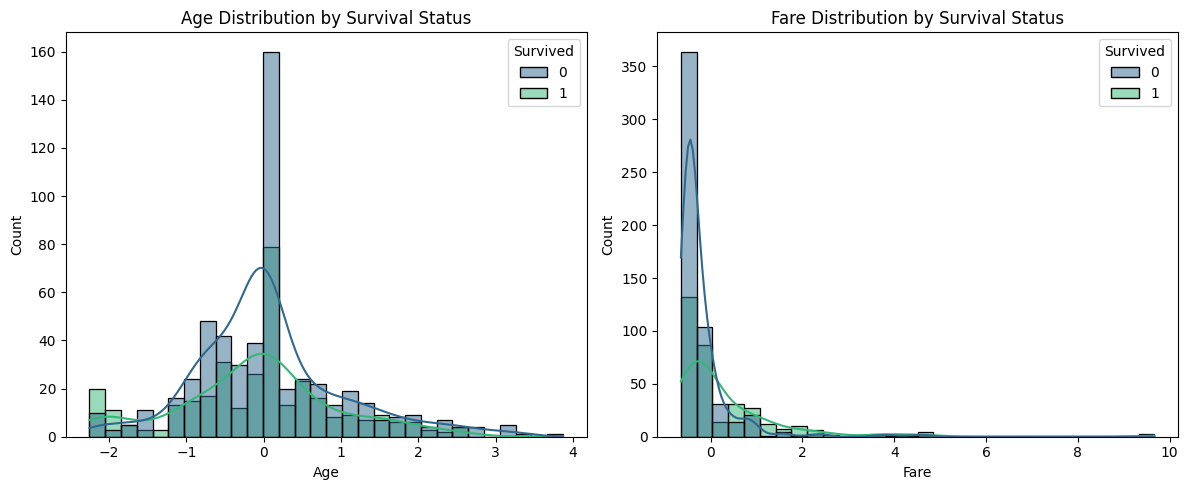

Distribution comparisons generated successfully.


In [ ]:
print("Comparing 'Age' and 'Fare' distributions between Survived and Not Survived groups...")

# Compare 'Age' distribution between 'Survived' and 'Not Survived'
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(data=train_df_eda, x='Age', hue='Survived', kde=True, bins=30, palette='viridis')
plt.title('Age Distribution by Survival Status')
plt.xlabel('Age')
plt.ylabel('Count')

# Compare 'Fare' distribution between 'Survived' and 'Not Survived'
plt.subplot(1, 2, 2)
sns.histplot(data=train_df_eda, x='Fare', hue='Survived', kde=True, bins=30, palette='viridis')
plt.title('Fare Distribution by Survival Status')
plt.xlabel('Fare')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

print("Distribution comparisons generated successfully.")

## Train Logistic Regression Model

### Subtask:
Initialize a `LogisticRegression` model from `sklearn.linear_model` and train it using the scaled training features (`X`) and the target variable (`y`).


**Reasoning**:
First, I need to import the `LogisticRegression` class from `sklearn.linear_model` to make it available for use. Then, I will instantiate and train the model using the prepared `X` and `y` data.



In [ ]:
from sklearn.linear_model import LogisticRegression

print("Initializing and training Logistic Regression model...")

# Instantiate Logistic Regression model
model = LogisticRegression(random_state=42, solver='liblinear') # Using 'liblinear' solver for small datasets and good performance

# Train the model
model.fit(X, y)

print("Logistic Regression model trained successfully.")

Initializing and training Logistic Regression model...
Logistic Regression model trained successfully.


**Reasoning**:
To evaluate the model's performance, I will first import necessary metrics from `sklearn.metrics`, then make predictions on the training data (`X`) using the trained `model`. Afterward, I will calculate and display the confusion matrix, accuracy, precision, recall, and F1-score.



In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

print("Evaluating Logistic Regression model performance...")

# Make predictions on the training data
y_pred = model.predict(X)

# Calculate and print Confusion Matrix
cm = confusion_matrix(y, y_pred)
print("\nConfusion Matrix:\n", cm)

# Calculate and print Accuracy
accuracy = accuracy_score(y, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Calculate and print Precision
precision = precision_score(y, y_pred)
print(f"Precision: {precision:.4f}")

# Calculate and print Recall
recall = recall_score(y, y_pred)
print(f"Recall: {recall:.4f}")

# Calculate and print F1-Score
f1 = f1_score(y, y_pred)
print(f"F1-Score: {f1:.4f}")

print("Model evaluation complete.")

Evaluating Logistic Regression model performance...

Confusion Matrix:
 [[477  72]
 [105 237]]
Accuracy: 0.8013
Precision: 0.7670
Recall: 0.6930
F1-Score: 0.7281
Model evaluation complete.


## Generate Predictions and Submission File

### Subtask:
Generate 'Survived' predictions on the scaled test data (`test_df_processed`) and create a 'submission.csv' file with 'PassengerId' from the original `test_df` and the generated predictions.

**Reasoning**:
Now that the model is trained, the next logical step is to use it to generate predictions on the preprocessed test data (`test_df_processed`).



In [ ]:
print("Generating predictions on test data...")

# Generate predictions on the scaled test data
predictions = model.predict(test_df_processed)

print("Predictions generated successfully. First 5 predictions:", predictions[:5])

Generating predictions on test data...
Predictions generated successfully. First 5 predictions: [0 0 0 0 1]


**Reasoning**:
Now that predictions are generated, the next step is to create the 'submission.csv' file by combining the original 'PassengerId' from `test_df` with the generated 'predictions', as specified in the subtask.



In [ ]:
print("Creating submission file...")

# Create a submission DataFrame
submission_df = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Survived': predictions
})

# Save the submission DataFrame to a CSV file
submission_df.to_csv('submission.csv', index=False)

print("Submission file 'submission.csv' created successfully. First 5 rows:")
display(submission_df.head())

Creating submission file...
Submission file 'submission.csv' created successfully. First 5 rows:


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


## Evaluate Logistic Regression Model

### Subtask:
Evaluate the performance of the trained Logistic Regression model using a Confusion Matrix, Accuracy, Precision, Recall, and F1-Score.

## Evaluate Logistic Regression Model

### Subtask:
Evaluate the performance of the trained Logistic Regression model using a Confusion Matrix, Accuracy, Precision, Recall, and F1-Score.

## Final Task

### Subtask:
Summarize the preprocessing, EDA, model training, evaluation, and prediction generation steps performed.


## Summary:

### Data Analysis Key Findings

*   **Data Preprocessing:**
    *   The missing 'Fare' value in the test dataset was successfully imputed using the mean 'Fare' from the training dataset.
    *   Test data columns were aligned with training features, and 'PassengerId', 'Name', and 'Ticket' were dropped, resulting in a processed test DataFrame of shape (418, 8).
    *   Boolean columns ('Sex_male', 'Embarked_Q', 'Embarked_S') in both training and test datasets were converted to integer type (0s and 1s).
    *   Numerical features ('Age', 'SibSp', 'Parch', 'Fare') in both datasets were standardized using `StandardScaler`, fitted exclusively on the training data to prevent data leakage.
*   **Exploratory Data Analysis (EDA):**
    *   Histograms revealed that 'Fare' was heavily skewed towards lower values, while 'Age' showed a somewhat normal distribution with a peak in younger adults.
    *   A correlation heatmap highlighted key relationships with 'Survived': 'Sex_male' showed a strong negative correlation (-0.54), 'Pclass' a negative correlation (-0.34), and 'Fare' a positive correlation (0.26). 'Age' had a weak negative correlation (-0.077).
    *   Comparison of distributions by survival status indicated that higher fare passengers and children showed a higher tendency to survive, while the "Not Survived" group had a slightly higher concentration of adults.
*   **Model Training and Evaluation:**
    *   A Logistic Regression model was successfully trained on the scaled training data.
    *   The model achieved the following performance metrics on the training data:
        *   Accuracy: 0.8013
        *   Precision: 0.7670
        *   Recall: 0.6930
        *   F1-Score: 0.7281
    *   The confusion matrix was `[[477 72] [105 237]]`, indicating 477 True Negatives, 72 False Positives, 105 False Negatives, and 237 True Positives.
*   **Prediction Generation:**
    *   Predictions were generated on the scaled test data using the trained Logistic Regression model.
    *   A `submission.csv` file was successfully created, containing 'PassengerId' and the corresponding 'Survived' predictions.

### Insights or Next Steps

*   The current model performance is reasonable on the training data. To assess its generalization capability and prevent overfitting, perform cross-validation or split the training data into training and validation sets for evaluation.
*   Given the insights from EDA (e.g., strong correlation of 'Sex', 'Pclass', 'Fare' with 'Survived'), consider exploring feature engineering techniques such as creating interaction terms or polynomial features to potentially improve model performance.


## Final Task

### Subtask:
Review the generated presentation content and confirm its completeness and clarity.
